# Lab Experiment 1 — Multimodal Healthcare Data Ingestion

**Course:** CSET343 — AI in Healthcare  
**Objective:** Read and inspect tabular, textual, image, signal, and medical data in different formats.


In [1]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

import wfdb

pd.set_option("display.max_columns", None)


In [2]:
def load_tabular(path):
    """Load CSV, Excel, or JSON based on file extension."""
    ext = os.path.splitext(path)[1].lower()
    if ext == ".csv":
        return pd.read_csv(path)
    if ext in (".xls", ".xlsx"):
        return pd.read_excel(path)
    if ext == ".json":
        return pd.read_json(path)
    raise ValueError(f"Unsupported tabular format: {ext}")


def inspect_dataframe(df, name="DataFrame"):
    print(f"--- {name} ---")
    print("Shape:", df.shape)
    print("\nData types:")
    display(df.dtypes.to_frame("dtype"))
    print("\nMissing values:")
    display(df.isna().sum().to_frame("missing"))
    print("\nPreview:")
    display(df.head())


def load_text(path):
    with open(path, "r", encoding="utf-8") as f:
        return f.read()


def tokenize(text):
    return re.findall(r"[A-Za-z]+", text.lower())


In [3]:
uci_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

heart = pd.read_csv(
    uci_url,
    header=None,
    names=columns,
    na_values="?"
)

inspect_dataframe(heart, "Cleveland Heart Disease Dataset")


--- Cleveland Heart Disease Dataset ---
Shape: (303, 14)

Data types:


,dtype
age,float64
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64



Missing values:


,missing
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0



Preview:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
heart_clean = heart.copy()
heart_clean["target_binary"] = (heart_clean["target"] > 0).astype(int)
heart_clean = heart_clean.drop(columns=["target"])

print("Rows:", len(heart_clean))
print("Missing values before modeling:")
display(heart_clean.isna().sum().to_frame("missing"))

print("\nBinary target distribution:")
display(heart_clean["target_binary"].value_counts().sort_index().to_frame("count"))


Rows: 303
Missing values before modeling:


,missing
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0



Binary target distribution:


,count
target_binary,
0,164
1,139


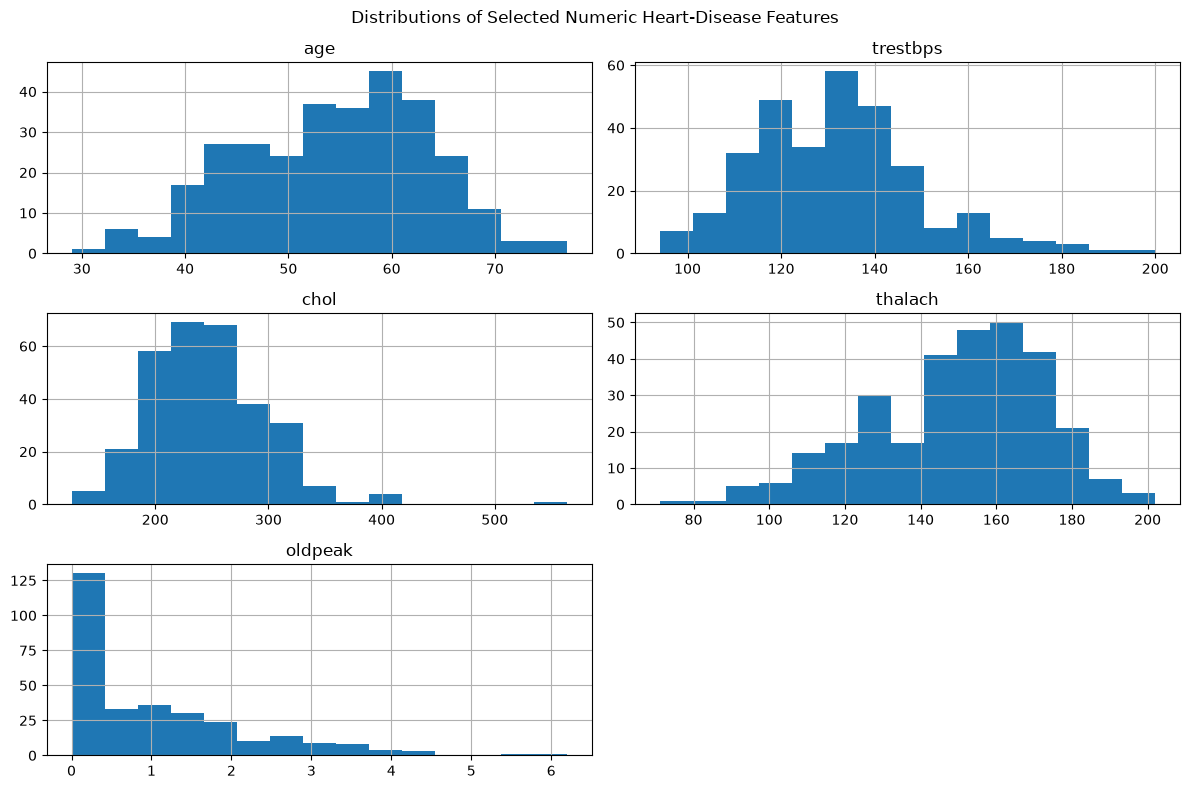

In [5]:
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

heart_clean[numeric_cols].hist(figsize=(12, 8), bins=15)
plt.suptitle("Distributions of Selected Numeric Heart-Disease Features")
plt.tight_layout()
plt.show()


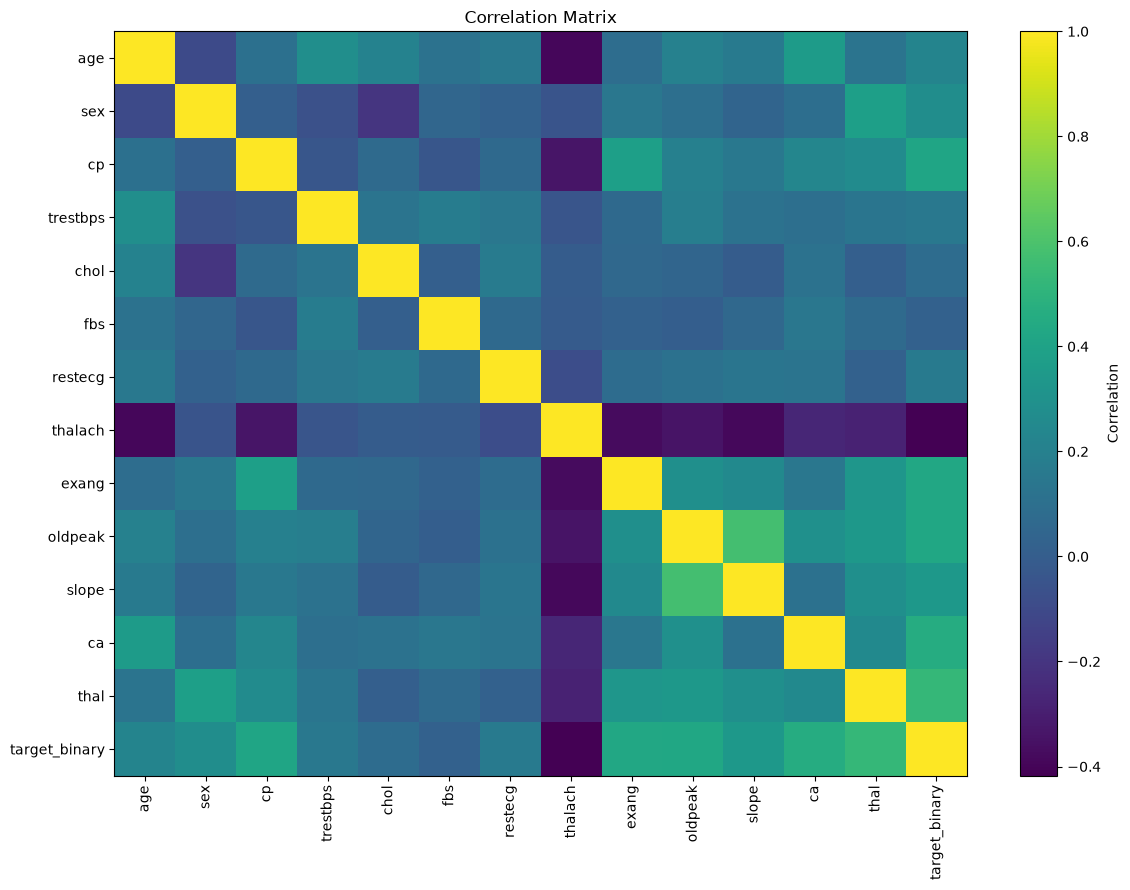

In [6]:
corr = heart_clean.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 9))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


In [7]:
X = heart_clean.drop(columns=["target_binary"])
y = heart_clean["target_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC:  {roc_auc:.4f}")
print("\nClassification report:")
print(classification_report(
    y_test, y_pred, target_names=["No disease", "Disease"]
))


Accuracy: 0.8689
ROC AUC:  0.9513

Classification report:
              precision    recall  f1-score   support

  No disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



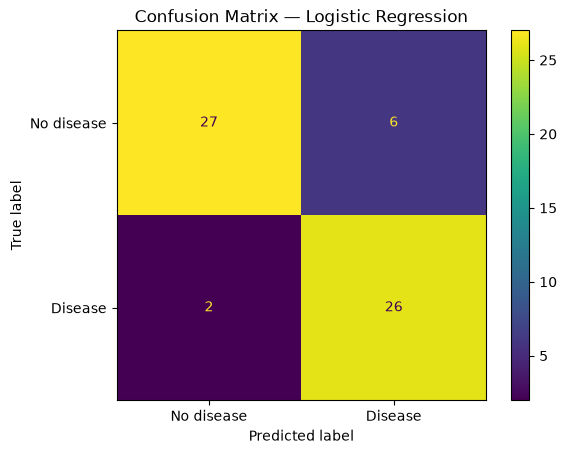

In [8]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No disease", "Disease"]
)
disp.plot()
plt.title("Confusion Matrix — Logistic Regression")
plt.show()


In [10]:
clinical_note = (
    "Patient reports intermittent chest pain during exertion for the past two weeks. "
    "The patient also reports shortness of breath and fatigue. "
    "No known recent infection. Resting symptoms are less severe than symptoms during physical activity."
)

text_path = "sample_clinical_note.txt"

with open(text_path, "w", encoding="utf-8") as f:
    f.write(clinical_note)

loaded_note = load_text(text_path)

print("Loaded clinical note:\n")
print(loaded_note)


Loaded clinical note:

Patient reports intermittent chest pain during exertion for the past two weeks. The patient also reports shortness of breath and fatigue. No known recent infection. Resting symptoms are less severe than symptoms during physical activity.


In [11]:
tokens = tokenize(loaded_note)

stopwords = {
    "the", "a", "an", "and", "or", "of", "for", "to", "is", "are",
    "during", "past", "also", "no", "known", "recent", "than",
    "with", "in", "on", "at"
}

filtered_tokens = [t for t in tokens if t not in stopwords]
word_freq = Counter(filtered_tokens)

print("Token count:", len(tokens))
print("Top terms:")
display(pd.DataFrame(
    word_freq.most_common(15),
    columns=["term", "frequency"]
))


Token count: 35
Top terms:


,term,frequency
0,patient,2
1,reports,2
2,symptoms,2
3,intermittent,1
4,chest,1
5,pain,1
6,exertion,1
7,two,1
8,weeks,1
9,shortness,1


Format: PNG
Mode: L
Size: (512, 512)
Metadata: {}


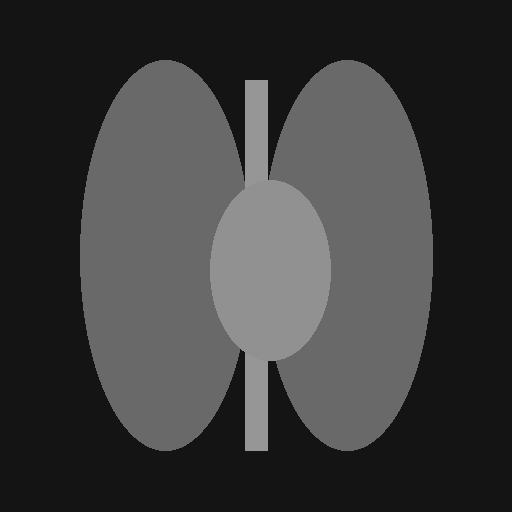

In [12]:
img_path = "synthetic_medical_image.png"

img = Image.new("L", (512, 512), color=20)
draw = ImageDraw.Draw(img)

# Simple synthetic thorax-like shapes; NOT a real medical image.
draw.ellipse((80, 60, 250, 450), fill=105)
draw.ellipse((262, 60, 432, 450), fill=105)
draw.rectangle((245, 80, 267, 450), fill=150)
draw.ellipse((210, 180, 330, 360), fill=145)

img.save(img_path)

loaded_img = Image.open(img_path)

print("Format:", loaded_img.format)
print("Mode:", loaded_img.mode)
print("Size:", loaded_img.size)
print("Metadata:", loaded_img.info)

display(loaded_img)


Resized image size: (256, 256)


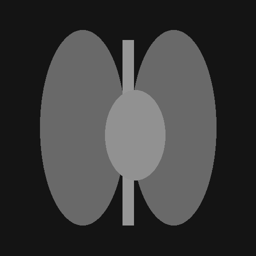

In [13]:
resized_img = loaded_img.resize((256, 256))

print("Resized image size:", resized_img.size)
display(resized_img)


In [14]:
record_name = "100"

record = wfdb.rdrecord(record_name, pn_dir="mitdb")
annotation = wfdb.rdann(record_name, "atr", pn_dir="mitdb")

print("Signal shape:", record.p_signal.shape)
print("Sampling frequency:", record.fs, "Hz")
print("Signal names:", record.sig_name)
print("Number of annotations:", len(annotation.sample))
print("First annotation symbols:", annotation.symbol[:20])


Signal shape: (650000, 2)
Sampling frequency: 360 Hz
Signal names: ['MLII', 'V5']
Number of annotations: 2274
First annotation symbols: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


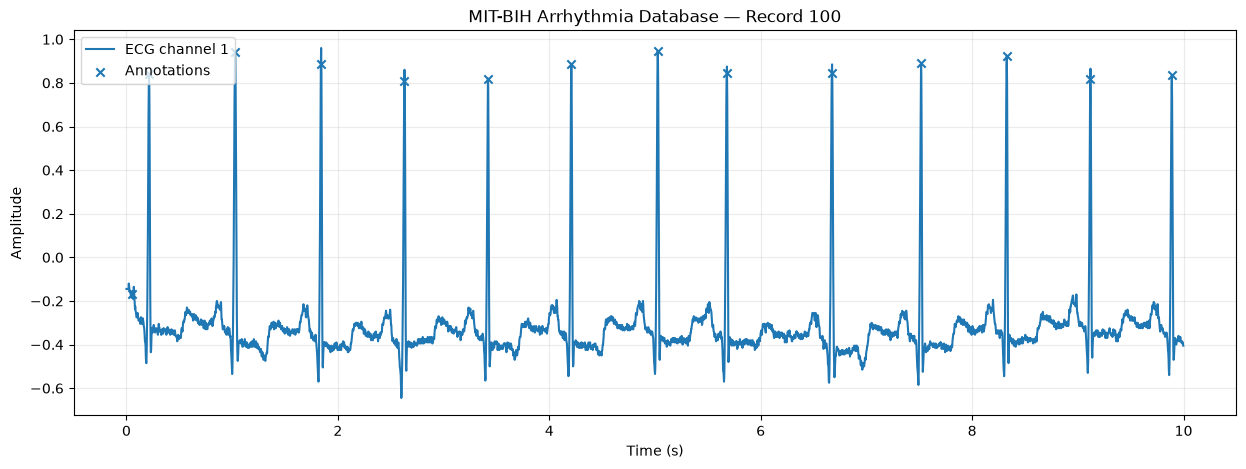

Annotations in plotted segment:
[(np.int64(18), np.str_('+')), (np.int64(77), np.str_('N')), (np.int64(370), np.str_('N')), (np.int64(662), np.str_('N')), (np.int64(946), np.str_('N')), (np.int64(1231), np.str_('N')), (np.int64(1515), np.str_('N')), (np.int64(1809), np.str_('N')), (np.int64(2044), np.str_('A')), (np.int64(2402), np.str_('N')), (np.int64(2706), np.str_('N')), (np.int64(2998), np.str_('N')), (np.int64(3282), np.str_('N')), (np.int64(3560), np.str_('N'))]


In [15]:
seconds_to_plot = 10
n_samples = int(seconds_to_plot * record.fs)

signal = record.p_signal[:n_samples, 0]
time = np.arange(n_samples) / record.fs

mask = annotation.sample < n_samples
ann_samples = annotation.sample[mask]
ann_symbols = np.array(annotation.symbol)[mask]

plt.figure(figsize=(15, 5))
plt.plot(time, signal, label="ECG channel 1")
plt.scatter(
    ann_samples / record.fs,
    signal[ann_samples],
    marker="x",
    label="Annotations"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("MIT-BIH Arrhythmia Database — Record 100")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print("Annotations in plotted segment:")
print(list(zip(ann_samples[:30], ann_symbols[:30])))


In [16]:
normal_samples = annotation.sample[np.array(annotation.symbol) == "N"]

rr_seconds = np.diff(normal_samples) / record.fs
rr_seconds = rr_seconds[(rr_seconds > 0.3) & (rr_seconds < 2.0)]

heart_rate_bpm = 60 / rr_seconds

print(f"Number of usable normal-beat intervals: {len(rr_seconds)}")
print(f"Mean RR interval: {rr_seconds.mean():.3f} s")
print(f"SD of RR intervals: {rr_seconds.std(ddof=1):.3f} s")
print(f"Mean estimated heart rate: {heart_rate_bpm.mean():.2f} BPM")


Number of usable normal-beat intervals: 2238
Mean RR interval: 0.807 s
SD of RR intervals: 0.101 s
Mean estimated heart rate: 75.06 BPM


In [17]:
manifest = {
    "experiment": "Lab Experiment 1",
    "tabular_dataset": "UCI Cleveland Heart Disease Dataset",
    "signal_dataset": "MIT-BIH Arrhythmia Database, record 100",
    "text_data": "Synthetic clinical note",
    "image_data": "Synthetic grayscale medical-image placeholder",
    "tabular_loader": "pandas",
    "signal_loader": "wfdb",
    "text_loader": "Python open()",
    "image_loader": "Pillow",
    "model": "Logistic Regression"
}

print(json.dumps(manifest, indent=2))


{
  "experiment": "Lab Experiment 1",
  "tabular_dataset": "UCI Cleveland Heart Disease Dataset",
  "signal_dataset": "MIT-BIH Arrhythmia Database, record 100",
  "text_data": "Synthetic clinical note",
  "image_data": "Synthetic grayscale medical-image placeholder",
  "tabular_loader": "pandas",
  "signal_loader": "wfdb",
  "text_loader": "Python open()",
  "image_loader": "Pillow",
  "model": "Logistic Regression"
}
